# Exploratory Data Analysis: NASA C-MAPSS Turbofan Engine Degradation

This notebook documents the dataset structure, motivates the preprocessing choices in `scripts/prepare_data.py`, and produces the eight required visualizations for Phase 1.

All figures are also saved to `results/eda/` as PNGs.

In [1]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    ALL_SENSOR_COLS,
    CMAPSS_SUBSETS,
    INTERIM_DIR,
    OP_SETTING_COLS,
    PROCESSED_DIR,
    PREDICTION_HORIZONS,
    RESULTS_DIR,
    RUL_CEILING,
)
from src.data.load import load_cmapss_train
from src.data.preprocess import add_rul_to_train
from src.utils.plotting import configure_plot_style
from src.utils.seeds import set_seeds

set_seeds(42)
configure_plot_style()

EDA_DIR = RESULTS_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

with open(PROCESSED_DIR / 'manifest.json') as f:
    manifest = json.load(f)
manifest_df = pd.DataFrame(manifest)
print(f'Loaded manifest with {len(manifest_df)} subsets')

Loaded manifest with 4 subsets


## 1. Dataset overview

FD001 and FD003 have one operating condition; FD002 and FD004 have six. FD001 has the simplest fault mode and is our primary benchmark.

        train_engines  train_cycles  test_engines  test_cycles  sensors_kept  flat_dropped
subset                                                                                    
FD001             100         20631           100        13096            14             7
FD002             260         53759           259        33991            20             1
FD003             100         24720           100        16596            15             6
FD004             249         61249           248        41214            20             1


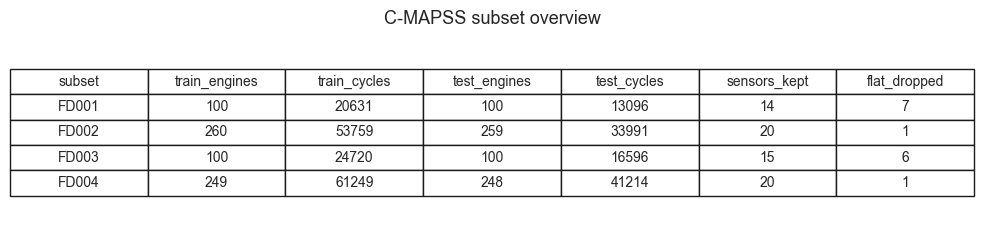

In [2]:
rows = []
for subset in CMAPSS_SUBSETS:
    train = pd.read_parquet(INTERIM_DIR / f'{subset}_train.parquet')
    test = pd.read_parquet(INTERIM_DIR / f'{subset}_test.parquet')
    sub_manifest = next(m for m in manifest if m['subset'] == subset)
    rows.append({
        'subset': subset,
        'train_engines': train['unit'].nunique(),
        'train_cycles': len(train),
        'test_engines': test['unit'].nunique(),
        'test_cycles': len(test),
        'sensors_kept': sub_manifest['n_features'],
        'flat_dropped': len(sub_manifest['flat_sensors_dropped']),
    })
overview = pd.DataFrame(rows).set_index('subset')
print(overview.to_string())

# Render as a saved figure too
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')
table = ax.table(
    cellText=overview.reset_index().values,
    colLabels=['subset'] + list(overview.columns),
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.6)
ax.set_title('C-MAPSS subset overview', pad=12)
fig.tight_layout()
fig.savefig(EDA_DIR / '01_dataset_overview.png', bbox_inches='tight', dpi=120)
plt.show()

## 2. Engine lifetime distribution

Engines fail at very different cycle counts both within and across subsets. This variability is why we split by *engine* rather than by *cycle*: shuffling cycles would let model fit and validation see the same engine and silently leak information about its degradation trajectory.

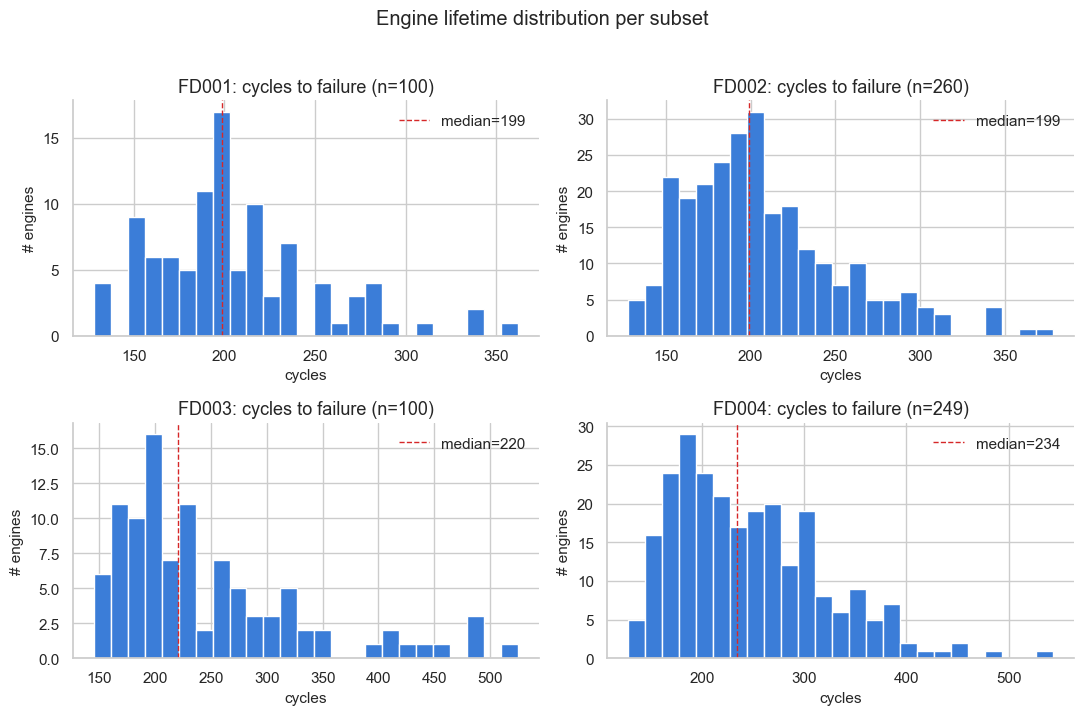

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=False)
for ax, subset in zip(axes.flat, CMAPSS_SUBSETS):
    train = pd.read_parquet(INTERIM_DIR / f'{subset}_train.parquet')
    lifetimes = train.groupby('unit')['cycle'].max()
    ax.hist(lifetimes, bins=25, color='#3b7dd8', edgecolor='white')
    ax.set_title(f'{subset}: cycles to failure (n={len(lifetimes)})')
    ax.set_xlabel('cycles')
    ax.set_ylabel('# engines')
    ax.axvline(lifetimes.median(), color='#d62728', linestyle='--', linewidth=1, label=f'median={int(lifetimes.median())}')
    ax.legend()
fig.suptitle('Engine lifetime distribution per subset', y=1.02)
fig.tight_layout()
fig.savefig(EDA_DIR / '02_engine_lifetimes.png', bbox_inches='tight', dpi=120)
plt.show()

## 3. RUL distribution: raw vs piecewise-linear ceiling

FD001 training set, every cycle of every engine. The 125-cycle ceiling reflects the practical reality that engines far from failure are not 'predictably' at any specific RUL — the regression target should saturate during the healthy phase and only become informative as degradation appears.

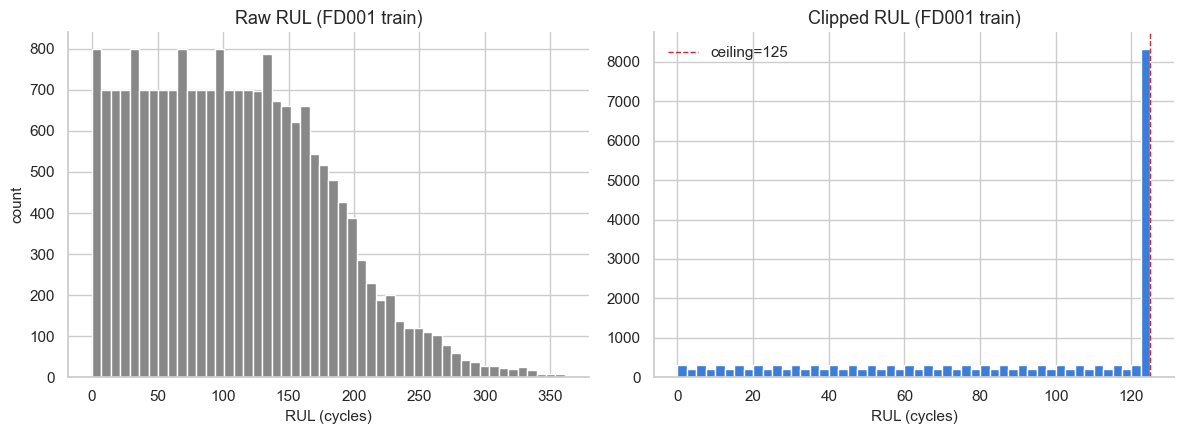

In [4]:
train = load_cmapss_train('FD001')
train = add_rul_to_train(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(train['rul'], bins=50, color='#888888', edgecolor='white')
axes[0].set_title('Raw RUL (FD001 train)')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('count')
axes[1].hist(train['rul_clipped'], bins=50, color='#3b7dd8', edgecolor='white')
axes[1].axvline(RUL_CEILING, color='#d62728', linestyle='--', linewidth=1, label=f'ceiling={RUL_CEILING}')
axes[1].set_title('Clipped RUL (FD001 train)')
axes[1].set_xlabel('RUL (cycles)')
axes[1].legend()
fig.tight_layout()
fig.savefig(EDA_DIR / '03_rul_clipping.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Sensor distributions: before vs after standardization

Box plots of all 21 raw sensors on FD001 train (left) versus the post-normalization distributions (right). Sensors that look like vertical lines on the raw side are the flat sensors automatically dropped from the feature set; on the normalized side only the kept sensors are shown.

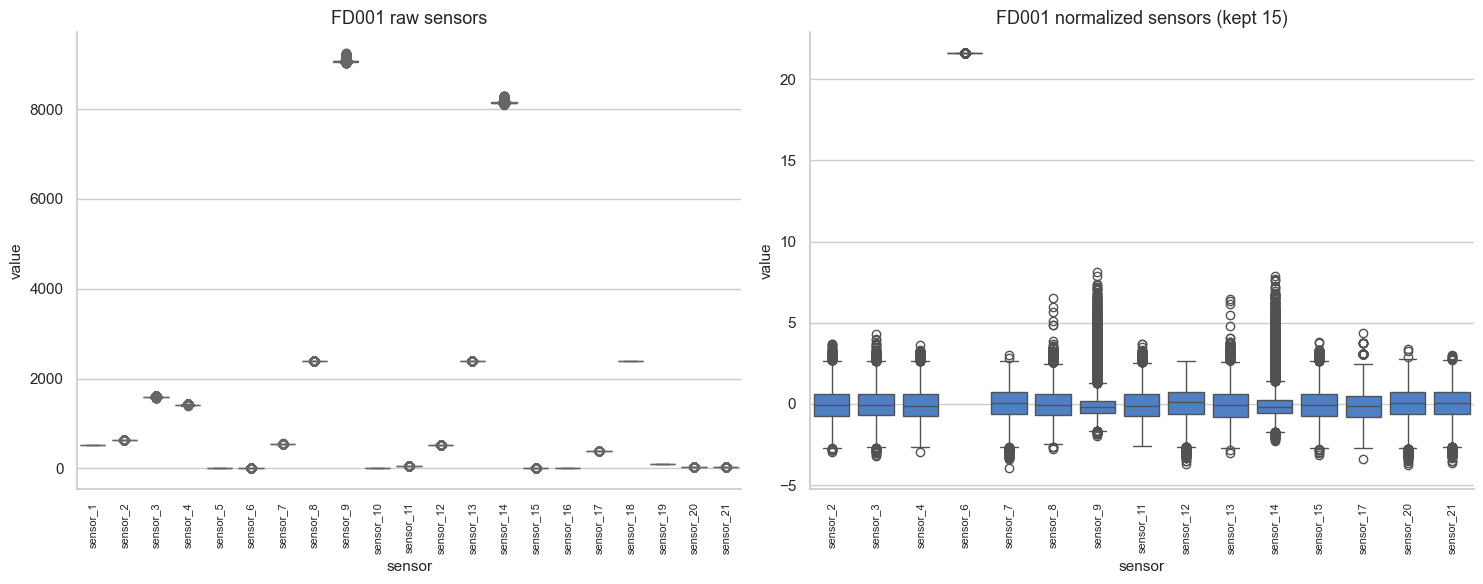

In [5]:
raw = load_cmapss_train('FD001')[ALL_SENSOR_COLS]
normalized = pd.read_parquet(INTERIM_DIR / 'FD001_train.parquet')
kept_cols = [c for c in ALL_SENSOR_COLS if c in normalized.columns and normalized[c].std() > 1e-3]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
raw.melt(var_name='sensor', value_name='value').pipe(
    lambda d: sns.boxplot(data=d, x='sensor', y='value', ax=axes[0], color='#aaaaaa')
)
axes[0].set_title('FD001 raw sensors')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

normalized[kept_cols].melt(var_name='sensor', value_name='value').pipe(
    lambda d: sns.boxplot(data=d, x='sensor', y='value', ax=axes[1], color='#3b7dd8')
)
axes[1].set_title(f'FD001 normalized sensors (kept {len(kept_cols)})')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
fig.tight_layout()
fig.savefig(EDA_DIR / '04_sensor_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. Sensor degradation trajectories

Three FD001 training engines (units 1, 50, 100), all kept sensors plotted across the engine's full lifetime, with a vertical line at failure. Some sensors visibly drift toward end-of-life; others show no useful trend. The visible-trend sensors are the ones we'd expect to dominate any RUL model.

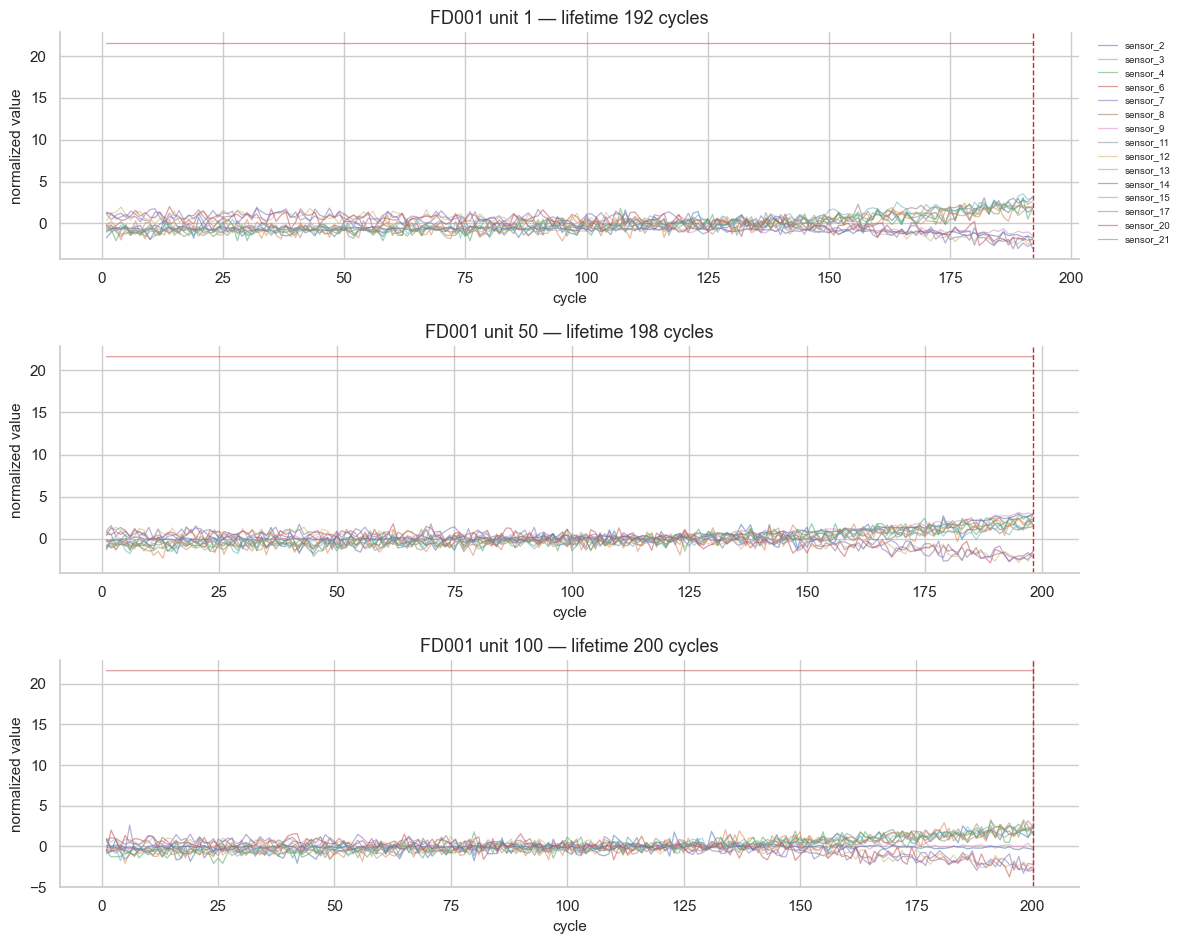

In [6]:
normalized = pd.read_parquet(INTERIM_DIR / 'FD001_train.parquet')
kept_cols = [c for c in ALL_SENSOR_COLS if c in normalized.columns and normalized[c].std() > 1e-3]

units_to_plot = [1, 50, 100]
fig, axes = plt.subplots(len(units_to_plot), 1, figsize=(12, 3.2 * len(units_to_plot)), sharex=False)
for ax, u in zip(axes, units_to_plot):
    g = normalized[normalized['unit'] == u].sort_values('cycle')
    for col in kept_cols:
        ax.plot(g['cycle'], g[col], alpha=0.55, linewidth=0.9, label=col)
    failure_cycle = g['cycle'].max()
    ax.axvline(failure_cycle, color='#d62728', linestyle='--', linewidth=1)
    ax.set_title(f'FD001 unit {u} — lifetime {failure_cycle} cycles')
    ax.set_xlabel('cycle')
    ax.set_ylabel('normalized value')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=7, ncol=1)
fig.tight_layout()
fig.savefig(EDA_DIR / '05_degradation_trajectories.png', bbox_inches='tight', dpi=120)
plt.show()

## 6. Per-sensor correlation with clipped RUL (FD001)

Pearson correlation between each kept FD001 sensor and `rul_clipped`, sorted by absolute strength. Sensors at the top carry the strongest linear signal about remaining life and we expect them to be heavily weighted by classical models.

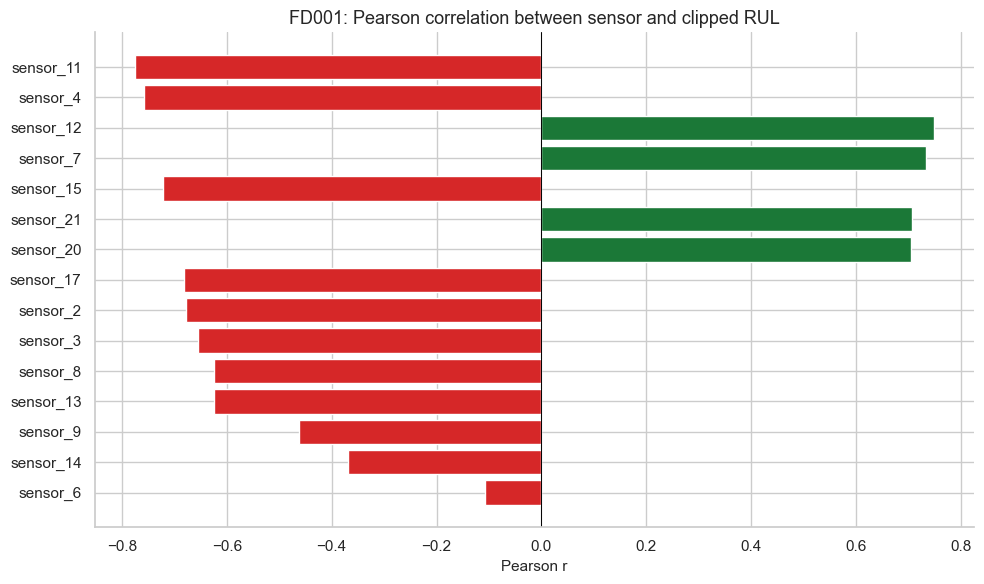

In [7]:
normalized = pd.read_parquet(INTERIM_DIR / 'FD001_train.parquet')
kept_cols = [c for c in ALL_SENSOR_COLS if c in normalized.columns and normalized[c].std() > 1e-3]

corr = normalized[kept_cols + ['rul_clipped']].corr()['rul_clipped'].drop('rul_clipped')
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if v < 0 else '#1b7837' for v in corr_sorted.values]
ax.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color=colors[::-1])
ax.set_title('FD001: Pearson correlation between sensor and clipped RUL')
ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', linewidth=0.7)
fig.tight_layout()
fig.savefig(EDA_DIR / '06_sensor_rul_correlation.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Operating regime clustering (FD002)

Operational settings 1, 2, 3 plotted pairwise, colored by KMeans regime cluster. FD002 and FD004 fly under six discrete operating conditions, each of which scales the sensor responses very differently. Without per-regime normalization, sensor fluctuations would be dominated by which condition the engine is in rather than by underlying degradation.

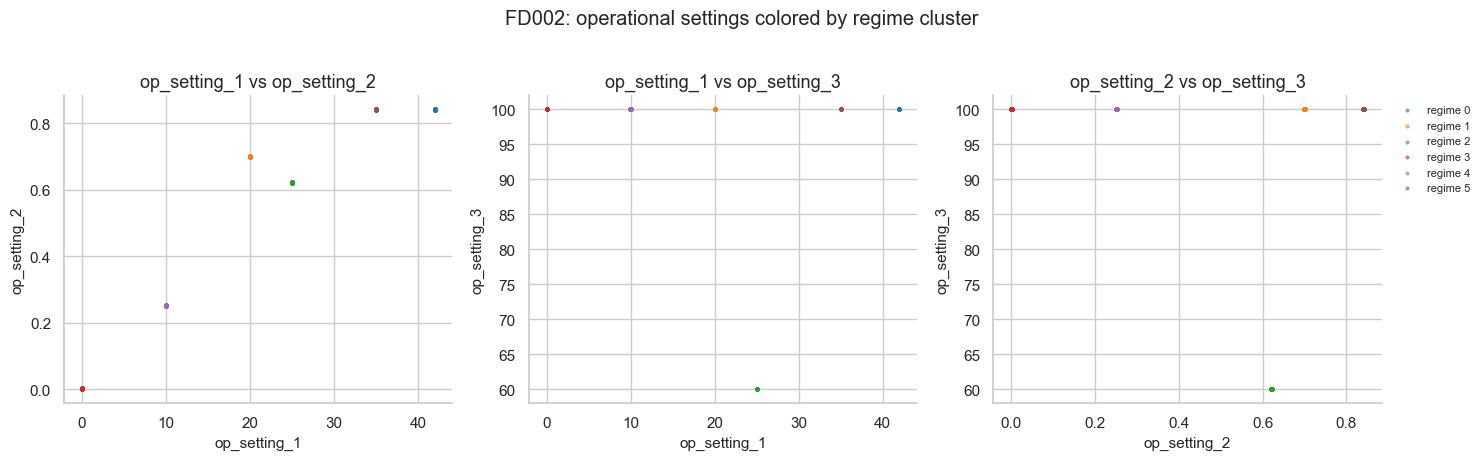

In [8]:
fd002 = pd.read_parquet(INTERIM_DIR / 'FD002_train.parquet')
regimes = fd002['regime'].astype(int)
n_regimes = regimes.nunique()
palette = sns.color_palette('tab10', n_colors=n_regimes)

pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (i, j) in zip(axes, pairs):
    xi, xj = OP_SETTING_COLS[i], OP_SETTING_COLS[j]
    for r in sorted(regimes.unique()):
        mask = regimes == r
        ax.scatter(
            fd002.loc[mask, xi], fd002.loc[mask, xj],
            s=4, alpha=0.5, color=palette[r], label=f'regime {r}'
        )
    ax.set_xlabel(xi)
    ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}')
axes[-1].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8)
fig.suptitle('FD002: operational settings colored by regime cluster', y=1.02)
fig.tight_layout()
fig.savefig(EDA_DIR / '07_op_regimes_fd002.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. Class balance for binary failure labels (FD001)

Per-cycle class balance for `failure_within_{H}` for H ∈ {10, 30, 50}. The shorter the horizon, the rarer the positive class. Highly imbalanced labels — especially H=10 — make raw accuracy useless; downstream evaluation will lean on PR-AUC, F1, and per-horizon calibration.

         positive  negative  pos_count  total
horizon                                      
H=10     0.053318  0.946682       1100  20631
H=30     0.150259  0.849741       3100  20631
H=50     0.247201  0.752799       5100  20631


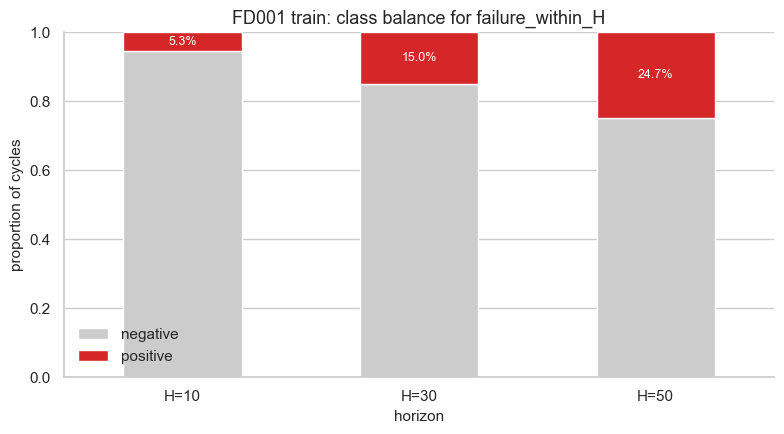

In [9]:
fd001 = pd.read_parquet(INTERIM_DIR / 'FD001_train.parquet')
rows = []
for h in PREDICTION_HORIZONS:
    pos = (fd001[f'failure_within_{h}'] == 1).sum()
    neg = (fd001[f'failure_within_{h}'] == 0).sum()
    total = pos + neg
    rows.append({'horizon': f'H={h}', 'positive': pos / total, 'negative': neg / total, 'pos_count': int(pos), 'total': int(total)})
balance = pd.DataFrame(rows).set_index('horizon')
print(balance)

fig, ax = plt.subplots(figsize=(8, 4.5))
balance[['negative', 'positive']].plot(kind='bar', stacked=True, ax=ax, color=['#cccccc', '#d62728'])
ax.set_title('FD001 train: class balance for failure_within_H')
ax.set_ylabel('proportion of cycles')
ax.set_ylim(0, 1)
for i, (_, row) in enumerate(balance.iterrows()):
    ax.text(i, row['negative'] + row['positive'] / 2,
            f"{row['positive']*100:.1f}%", ha='center', va='center', color='white', fontsize=9)
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(EDA_DIR / '08_class_balance_fd001.png', bbox_inches='tight', dpi=120)
plt.show()